# Clustering

"If intelligence was a cake, unsupervised learning would be the cake, supervised learning would be the icing on the cake, and reinforcement learning would be the cherry on the cake" - Yann LeCun

Análisis de Agrupamientos: Proceso de particionamiento de un conjunto de datos (u observaciones) en subconjuntos. Cada subconjunto es un grupo o cluster.

* Los datos en un mismo cluster deben ser similares entre sí.
* Los datos de diferentes clusters deben ser diferentes entre sí.

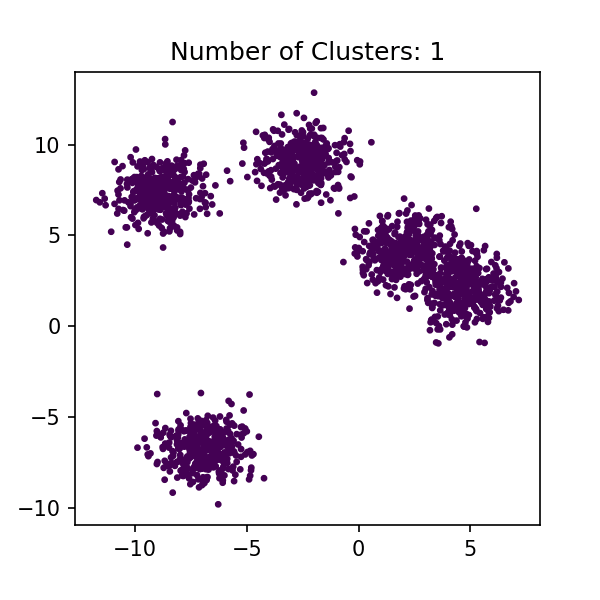

## K-Means

* Método que permite crear __clusters__ a partir de __datos numéricos__. El input del sistema son las mediciones numéricas de interés y los outputs son:
    * los centroides de los __clusters__ resultantes
    * la asignación de cada dato a un __cluster__ determinado.

* El __centroide__ es el punto que se encuentra en el centro de un __cluster__, (es la media de las coordenadas de todos los puntos de ese __cluster__).

* El número de centroides `k` es definido según convenga, para definir la distancia entre puntos y entre centroides se suele utilizar la distancia euclídea.

* La __inercia__ del modelo es la métrica de rendimiento usada para saber donde colocar mejor los centroides, la inercia del modelo es la
distancia media cuadrática entre cada observación y su centroide más cercano.

La Inercia o __Within sum of squares__ se obtiene:

$WSS = \sum_{i = 1}^{K}\sum_{j = 1}^{n_i}{\mid x_{ij} - c_i\mid}^2$

donde:

- $K$, es el número de centroides
- $n_i$, es el número de elementos que pertenecen al centroide $i$
- $c_i$, centroide del cluster $i$
- $x_{ij}$, elemento $j$ del cluster $i$

### Implementación en Scikit-learn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn import datasets

from pprint import pprint

In [ ]:
iris_dat = datasets.load_iris()
# pprint(iris_dat)
iris = (pd.DataFrame(iris_dat.data)
       .rename(columns={0:'sepal_length', 1:'sepal_width', 2:'petal_length', 3:'petal_width'})
       .assign(species=iris_dat.target))

iris.head(20)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


#### Inspección visual (ternary plot)

In [ ]:
import plotly.express as px
fig = px.scatter_ternary(iris,
                         a="sepal_length",
                         b="petal_length",
                         c="sepal_width",
                         size="petal_width",
                         size_max=12,
                         color="petal_width")
fig.show()

### Seleccionamos el numero de clusters

In [ ]:
X = iris.drop('species', axis=1)
y = iris['species']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42, stratify=y)

#### `n_clusters`

De forma arbitraria seleccionamos el valor del hiperparametro `n_clusters=3`

In [ ]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
model.fit(X_train)

KMeans(n_clusters=3)

#### `inertia_`

Obtenemos la inercia del modelo

In [ ]:
model.inertia_

109.92355865153083

También puede ser obtenido en su formato negativo bajo el protocolo de sklearn dónde "entre mas grande mejor"

In [ ]:
model.score(X_train)

-109.92355865153081

#### `cluster_centers_`

In [ ]:
model.cluster_centers_

array([[6.35294118, 2.88823529, 4.98382353, 1.70735294],
       [5.22105263, 3.72105263, 1.49473684, 0.27368421],
       [4.75      , 2.98333333, 1.67222222, 0.29444444]])

Obtenemos los centroides

In [ ]:
centroides_df = (pd.DataFrame(model.cluster_centers_)
                 .rename(columns={0:'sepal_length', 1:'sepal_width', 2:'petal_length', 3:'petal_width'})
)

In [ ]:
centroides_df

,sepal_length,sepal_width,petal_length,petal_width
0,6.352941,2.888235,4.983824,1.707353
1,5.221053,3.721053,1.494737,0.273684
2,4.750000,2.983333,1.672222,0.294444


In [ ]:
fig = px.scatter_ternary(centroides_df,
                         a="sepal_length",
                         b="petal_length",
                         c="sepal_width")
fig

In [ ]:
model.get_params(deep=True)

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 'auto',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [ ]:
model.get_metadata_routing()

{'fit': {'sample_weight': None}, 'score': {'sample_weight': None}}

### Agregamos nuevas observaciones a nuestros clusters

a __K-MEANS__ todo lo que importa al asignar una observación
a un cluster es la distancia al centroide.

In [ ]:
X_test

,sepal_length,sepal_width,petal_length,petal_width
107,7.3,2.9,6.3,1.8
63,6.1,2.9,4.7,1.4
133,6.3,2.8,5.1,1.5
56,6.3,3.3,4.7,1.6
127,6.1,3.0,4.9,1.8
140,6.7,3.1,5.6,2.4
53,5.5,2.3,4.0,1.3
69,5.6,2.5,3.9,1.1
20,5.4,3.4,1.7,0.2
141,6.9,3.1,5.1,2.3


In [ ]:
labels = model.predict(X_test)
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 0, 0, 1, 0, 2, 1, 2, 1, 0, 1,
       0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 1, 0, 1, 2, 2, 1, 0, 0, 1, 0, 0,
       0], dtype=int32)

In [ ]:
X_test['cluster'] = labels
X_test

,sepal_length,sepal_width,petal_length,petal_width,cluster
107,7.3,2.9,6.3,1.8,0
63,6.1,2.9,4.7,1.4,0
133,6.3,2.8,5.1,1.5,0
56,6.3,3.3,4.7,1.6,0
127,6.1,3.0,4.9,1.8,0
140,6.7,3.1,5.6,2.4,0
53,5.5,2.3,4.0,1.3,0
69,5.6,2.5,3.9,1.1,0
20,5.4,3.4,1.7,0.2,1
141,6.9,3.1,5.1,2.3,0


In [ ]:
pd.pivot_table(X_test, index='cluster')

,petal_length,petal_width,sepal_length,sepal_width
cluster,,,,
0,4.950000,1.692857,6.221429,2.914286
1,1.430000,0.260000,5.210000,3.560000
2,1.914286,0.471429,4.785714,2.942857


### Número optimo de clusters

#### Regla del codo

En general, no es fácil establecer el `k` optimo a priori y elegir el modelo con la menor inercia no es una buena idea ya que está regularmente disminuye a medida que aumentamos k, entonces La inercia no es una buena métrica de rendimiento.

In [ ]:
inertias = {k: KMeans(n_clusters=k).fit(X_train).inertia_ for k in range(1, 13)}
inertias

{1: 493.0771428571429,
 2: 116.32567632850245,
 3: 55.37572063492063,
 4: 39.915267857142844,
 5: 33.49556027164686,
 6: 26.12513479532163,
 7: 22.21369376968061,
 8: 20.34119590643276,
 9: 19.631252530364378,
 10: 18.563854636591476,
 11: 16.425483299595147,
 12: 15.034734188412212}

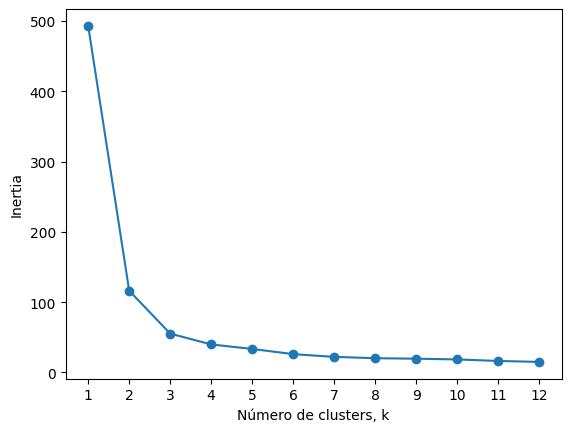

In [ ]:
plt.plot(list(inertias.keys()),
         list(inertias.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Inertia')
plt.xticks(list(inertias.keys()))
plt.show()

A medida que aumentamos k, la inercia cae muy rápid. Esta curva tiene aproximadamente la forma de un brazo, y hay un "codo" en k = 3.

__SI NO TUVIERAMOS MAS CONOCIMIENTO DE LOS DATOS k = 3 SERíA UNA BUENA OPCIÓN__

* Cualquier valor antes del codo sería dramático
* Cualquier valor despues del codo no ayudaría mucho, ya que podríamos simplemente estar dividiendo grupos perfectamente buenos por la mitad sin una buena razón.

Entonces, __si no hay información que ayude a tomar una mejor decisión, el valor del codo es la mejor opción__.

__NOTA__: En general este proceso no es sencillo y hay que tener en cuenta que K-Means es muy sensible a diferencias en las varianzas de las variables y a variables con escalas muy distintas.

#### Silhouette

* Un enfoque más preciso (pero también computacionalmente más costoso) es utilizar el __Silhouette score__.

* El __Silhouette score__ es el silhouette medio sobre todas las instancias.

* El Silhouette de una instancia se define cómo $\frac{b-a}{max(a, b)}$ dónde:
    * $a$ es la distancia media a otras instancias en el mismo cluster (la distancia intra cluster media)
    * $b$ es la media de la distancia al cluster mas cercano (la distancia media a las instancias del siguiente cluster, definida como la que minimiza a $b$, excluyendo la distancia del propio cluster)

* El coeficiente Silouette está entre -1 y 1 esto se interpreta:
    * Entre mas cerca está de 1, significa que la instancia está bien dentro de su cluster y lejos de otros clusters
    * Entre mas cerca está de 0, significa que está muy cerca de una frontera entre clusters
    * Entre mas cerca está de -1 significa que la instancia ha sido asignada a un cluster donde no corresponde

##### Silhouette scores

In [ ]:
from sklearn.metrics import silhouette_score

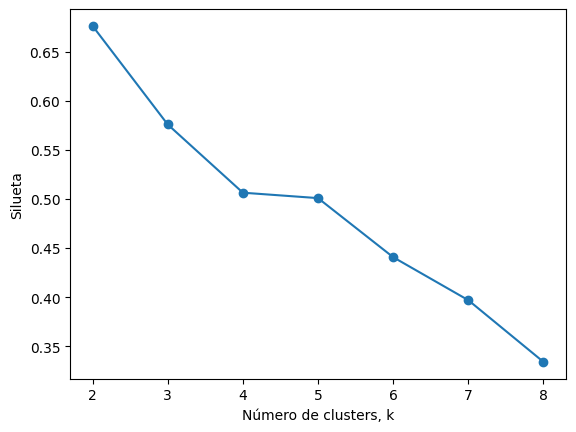

In [ ]:
silhouettes = {k: silhouette_score(X_train, KMeans(n_clusters=k).fit_predict(X_train)) for k in range(2, 9)}

plt.plot(list(silhouettes.keys()),
         list(silhouettes.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Silueta')
plt.xticks(list(silhouettes.keys()))
plt.show()

Está visualización es mas informativa que la gráfica del codo, en esta visualización observamos que `k=2` es un excelente `k`, pero `k=3` también es una excelente opción, estas opciones son mucho mejores que el resto, esta gráfica puede llegar a ser mas informativa que solo comparar inercias.

##### Silhouette diagrama

Una visualización aun mas informativa se obtiene cuando gráficamos el silhouette de cada instancia, agrupada por los clusters que los contiene y ordenada por sus valores.

Cada diagrama tiene forma de cuchillo por cluster:
* La altura del cuchillo significa la cantidad de instancias que contiene el cluster
* El ancho representa los coeficientes silhouette ordenados en el cluster (entre mas ancho mejor)
* La linea punteada representa el coeficiente silhouette medio

For n_clusters = 2, the average silhouette_score is: 0.6761
For n_clusters = 3, the average silhouette_score is: 0.5758
For n_clusters = 4, the average silhouette_score is: 0.5146
For n_clusters = 5, the average silhouette_score is: 0.4089
For n_clusters = 6, the average silhouette_score is: 0.3977
For n_clusters = 7, the average silhouette_score is: 0.3980
For n_clusters = 8, the average silhouette_score is: 0.3463


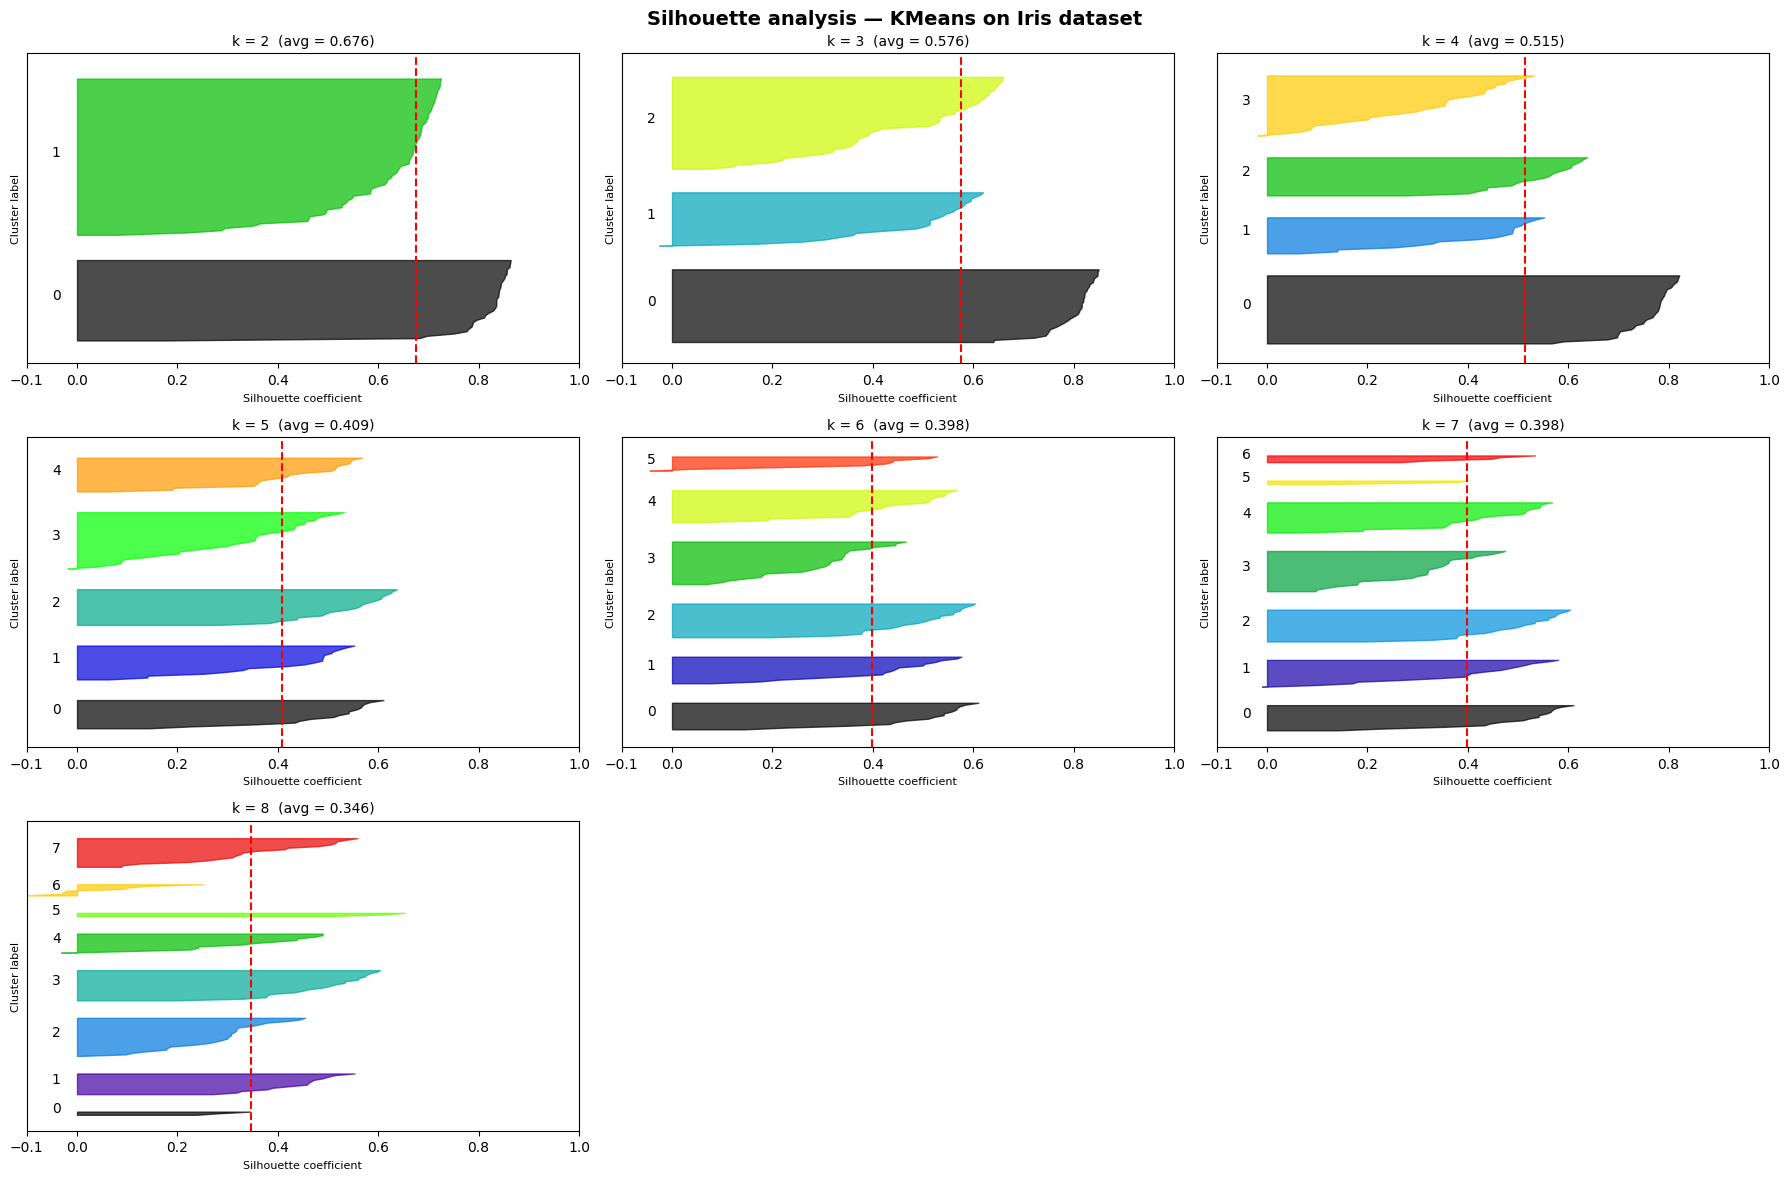

In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

n_clusters_range = range(2, 9)
n_plots = len(n_clusters_range)
cols = 3
rows = (n_plots + cols - 1) // cols  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for idx, k in enumerate(n_clusters_range):
    ax = axes[idx]

    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_train) + (k + 1) * 10])

    clusterer = KMeans(n_clusters=k, random_state=10, n_init='auto')
    cluster_labels = clusterer.fit_predict(X_train)

    silhouette_avg = silhouette_score(X_train, cluster_labels)
    print(f"For n_clusters = {k}, the average silhouette_score is: {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X_train, cluster_labels)

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f"k = {k}  (avg = {silhouette_avg:.3f})", fontsize=10)
    ax.set_xlabel("Silhouette coefficient", fontsize=8)
    ax.set_ylabel("Cluster label", fontsize=8)
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# Ocultar subplots sobrantes (si el total no es múltiplo de cols)
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Silhouette analysis — KMeans on Iris dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### Recomendaciones para K-means

* Normalizar las variables antes de hacer K-means, restar a cada variable su media y dividirla por la desviación típica